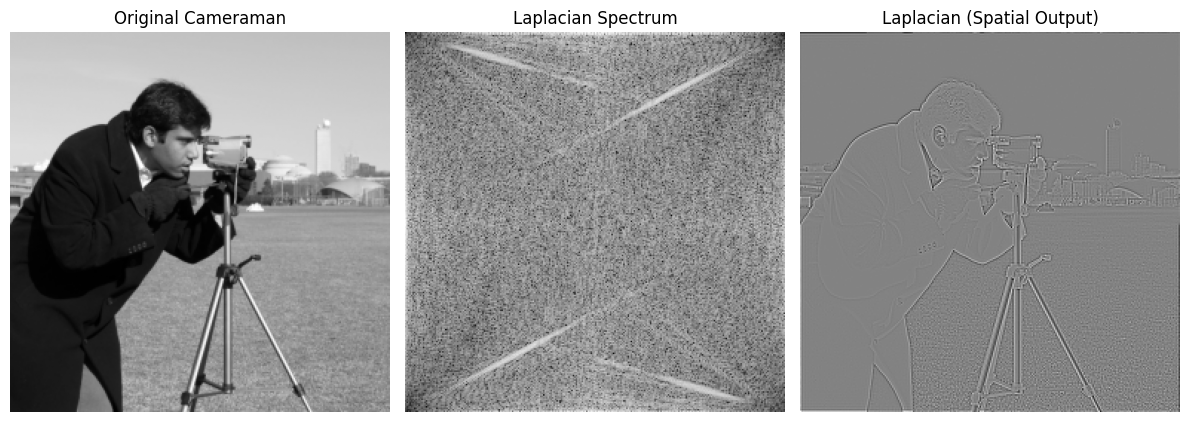

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from skimage.transform import resize

image = data.camera()
image = resize(image, (256, 256))  

M, N = image.shape
u = np.fft.fftfreq(M).reshape(-1, 1)
v = np.fft.fftfreq(N).reshape(1, -1)

laplacian_filter = -4 * (np.pi ** 2) * (u**2 + v**2)
F = np.fft.fft2(image)
F_lap = F * laplacian_filter


laplacian_image = np.fft.ifft2(F_lap).real
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(np.log(1 + np.abs(F_lap)), cmap='gray')
plt.title('Laplacian Spectrum')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(laplacian_image, cmap='gray')
plt.title('Laplacian (Spatial Output)')
plt.axis('off')

plt.tight_layout()
plt.show()

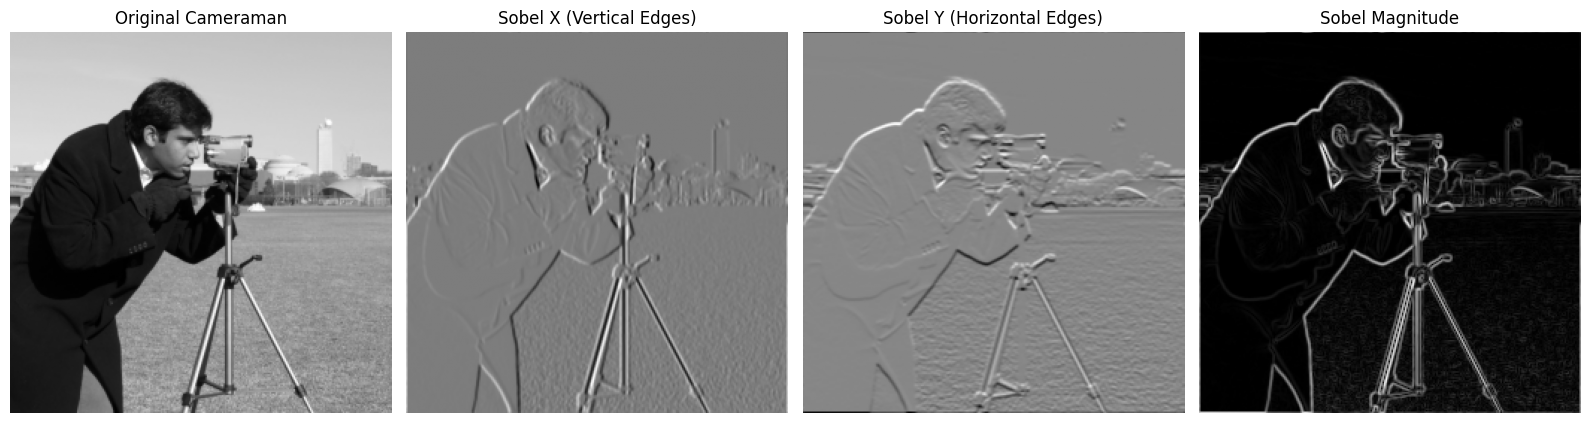

In [ ]:
from numpy.fft import fft2, ifft2, ifftshift

image = data.camera()
image = resize(image, (256, 256))

sobel_x = np.array([[-1,  0,  1],
                    [-2,  0,  2],
                    [-1,  0,  1]])

sobel_y = np.array([[-1, -2, -1],
                    [ 0,  0,  0],
                    [ 1,  2,  1]])

def center_embed_kernel(kernel, shape):
    padded = np.zeros(shape)
    kh, kw = kernel.shape
    ph, pw = shape
    
    cy, cx = ph // 2, pw // 2
    
    padded[cy - kh//2 : cy - kh//2 + kh, cx - kw//2 : cx - kw//2 + kw] = kernel
    
    return fft2(ifftshift(padded))

F_image = fft2(image)

F_sobel_x = center_embed_kernel(sobel_x, image.shape)
F_sobel_y = center_embed_kernel(sobel_y, image.shape)

G_x = F_image * F_sobel_x
G_y = F_image * F_sobel_y

sobel_x_spatial = ifft2(G_x).real
sobel_y_spatial = ifft2(G_y).real

sobel_magnitude = np.sqrt(sobel_x_spatial**2 + sobel_y_spatial**2)

plt.figure(figsize=(16, 5))

plt.subplot(1, 4, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Cameraman')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(sobel_x_spatial, cmap='gray')
plt.title('Sobel X (Vertical Edges)')
plt.axis('off')

#_______________________________
plt.subplot(1, 4, 3)
plt.imshow(sobel_y_spatial, cmap='gray')
plt.title('Sobel Y (Horizontal Edges)')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(sobel_magnitude, cmap='gray')
plt.title('Sobel Magnitude')
plt.axis('off')

plt.tight_layout()
plt.show()